In [27]:
using Distributed
procs_to_use = 112
if nprocs() <= procs_to_use
    addprocs(procs_to_use-nprocs())
end
;

In [28]:
@everywhere begin
    include("../misc/helper_functions.jl")
    include("../misc/compute_size_temperature.jl")
    include("define_F1_to_F0_prob.jl")
end

In [29]:
using DifferentialEquations
t_start = 0.0
t_end   = 30e-3
t_span  = (t_start, t_end) ./ (1/Γ)

p = initialize_prob(Float64, energies, freqs, sats, pols, k_relative, beam_radius, offsets, d, m/(ħ*k^2/Γ), Γ, k, sim_params, update_p!, add_terms_dψ!, 1:3, 4:4)

cb = DiscreteCallback(condition_discrete, stochastic_collapse_nokick!, save_positions=(false,false))
kwargs = (alg=DP5(), reltol=1e-4, abstol=1e-5, saveat=1000, maxiters=50000000, callback=cb)
prob = ODEProblem(ψ_update!, p.u0, t_span, p; kwargs...)
;

In [30]:
function d1(β)
    c = cos(β)
    s = sin(β)
    return [
        (1 + c)/2     s/sqrt(2)    (1 - c)/2;
       -s/sqrt(2)     c            s/sqrt(2);
        (1 - c)/2    -s/sqrt(2)    (1 + c)/2
    ]
end

using LinearAlgebra
function D1(α, β, γ)
    # Order m = [-1, 0, +1]
    m = [-1, 0, 1]
    L = Diagonal(exp.(-1im .* m .* α))
    R = Diagonal(exp.(-1im .* m .* γ))
    return L * d1(β) * R
end

D1 (generic function with 1 method)

In [31]:
prob.p.ϵs[1,1,:] .= D1(0, pi/2, 0) * pols[1]
prob.p.ϵs[4,1,:] .= D1(0, -pi/2, 0) * pols[1]
prob.p.ϵs[1,2,:] .= D1(0, pi/2, 0) * pols[2]
prob.p.ϵs[4,2,:] .= D1(0, -pi/2, 0) * pols[2]

prob.p.ϵs[2,1,:] .= D1(pi/2, pi/2, 0) * pols[1]
prob.p.ϵs[5,1,:] .= D1(-pi/2, pi/2, 0) * pols[1]
prob.p.ϵs[2,2,:] .= D1(pi/2, pi/2, 0) * pols[2]
prob.p.ϵs[5,2,:] .= D1(-pi/2, pi/2, 0) * pols[2]
;

In [32]:
@time sols = distributed_solve(100, prob, prob_func!, scan_nothing, [0])
;

Progress:  21%|████████▌                                |  ETA: 0:22:06

      From worker 66:	┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
      From worker 66:	└ @ SciMLBase ~/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:626


Progress:  34%|█████████████▊                           |  ETA: 0:18:42

      From worker 43:	┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
      From worker 43:	└ @ SciMLBase ~/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:626


Progress:  46%|██████████████████▉                      |  ETA: 0:15:13

...

      From worker 104:	┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
      From worker 104:	└ @ SciMLBase ~/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:626


Progress:  85%|███████████████████████████████████      |  ETA: 0:04:08

      From worker 50:	┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
      From worker 50:	└ @ SciMLBase ~/.julia/packages/SciMLBase/TZ9Rx/src/integrator_interface.jl:626


Progress: 100%|█████████████████████████████████████████| Time: 0:38:18


2322.340733 seconds (47.00 M allocations: 3.882 GiB, 0.43% gc time, 0.01% compilation time)


In [25]:
# sols_15 = deepcopy(sols)
# ;

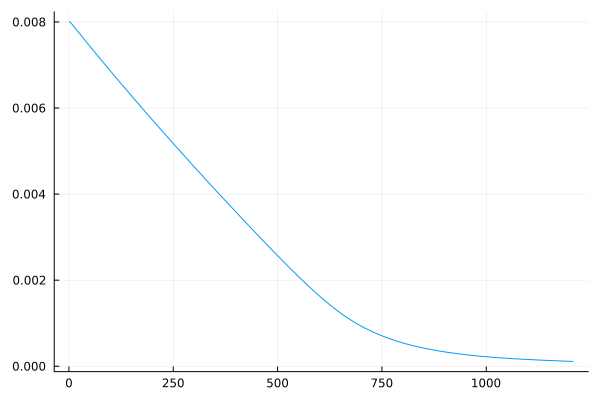

In [17]:
using Plots
survived_idxs = [abs(r(sol.u[end])) <= 10e-3 for sol in sols[1]]

xs = [x.(sol.u) for sol in sols[1][survived_idxs]]
ys = [y.(sol.u) for sol in sols[1][survived_idxs]]
zs = [z.(sol.u) for sol in sols[1][survived_idxs]]

vxs = [vx.(sol.u) for sol in sols[1][survived_idxs]]
vys = [vy.(sol.u) for sol in sols[1][survived_idxs]]
vzs = [vz.(sol.u) for sol in sols[1][survived_idxs]]

pos_mols = [x[1] > 0 for x in xs]

plot(mean(xs[pos_mols]), legend=nothing)

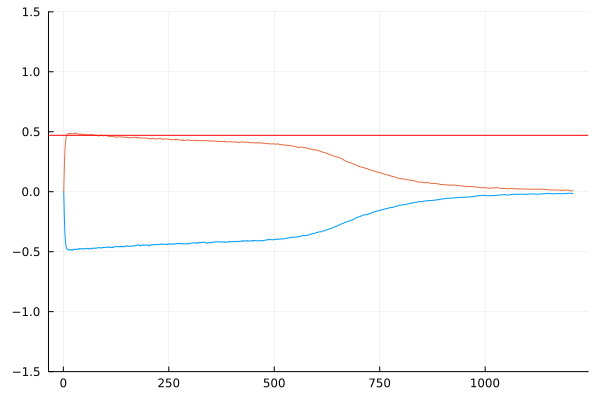

In [18]:
plot(mean(vxs[pos_mols]), legend=nothing, ylim=(-1.5,1.5))
plot!(mean(vxs[.~pos_mols]))
hline!([two_photon_det / (2 * 478e12) * c], color=:red)

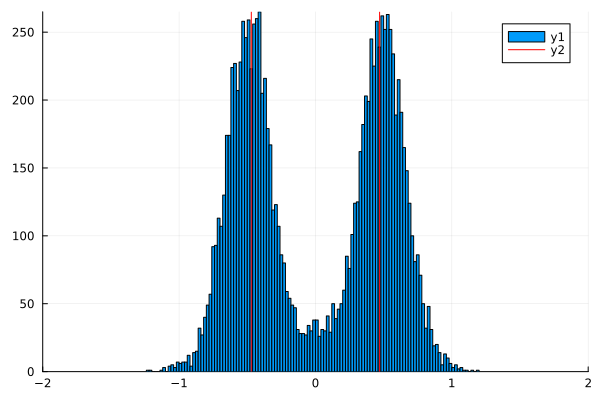

In [22]:
histogram([vx(sol.u[40]) for sol in sols[1]], xlim=(-2,2), bins=200)
vline!([-two_photon_det / (2 * 478e12) * c, two_photon_det / (2 * 478e12) * c], color=:red)